# IMPORTING THE DEPENDENCIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')


# DATA COLLECTION AND PREPROCESSING

In [2]:
df= pd.read_csv("../dataset/diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
#Getting some info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Checking for missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Check how many zeros are present in each column
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In this dataset, some features like Glucose, Blood Pressure, Skin Thickness, Insulin, and BMI contain zeros, which are not realistic in the real world. For example, no person can have a Glucose level or BMI of exactly zero. So, I treated these zeros as missing values.

Instead of dropping rows, which would reduce the already small dataset, I chose to impute them. I used the median because medical data is often skewed and has outliers, and the median is more robust than the mean in such cases. This way, the imputation does not distort the distribution. Pregnancies, however, can actually be zero, so I left that feature as it is.

In [8]:
cols_with_zeros = ["Glucose", "BloodPressure" ,"SkinThickness", "Insulin", "BMI"]
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

In [9]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

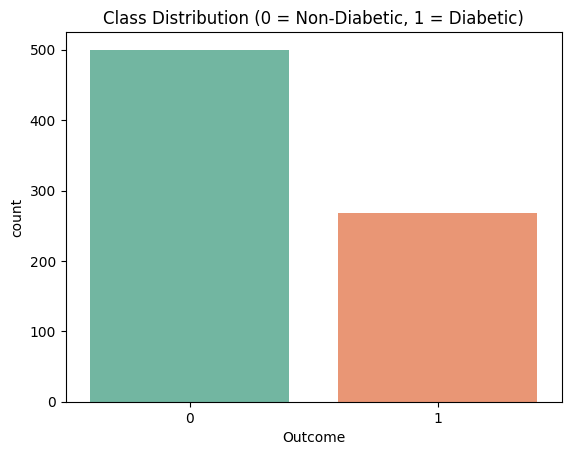

In [10]:
# Class balance
sns.countplot(x='Outcome', data=df, palette="Set2")
plt.title("Class Distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

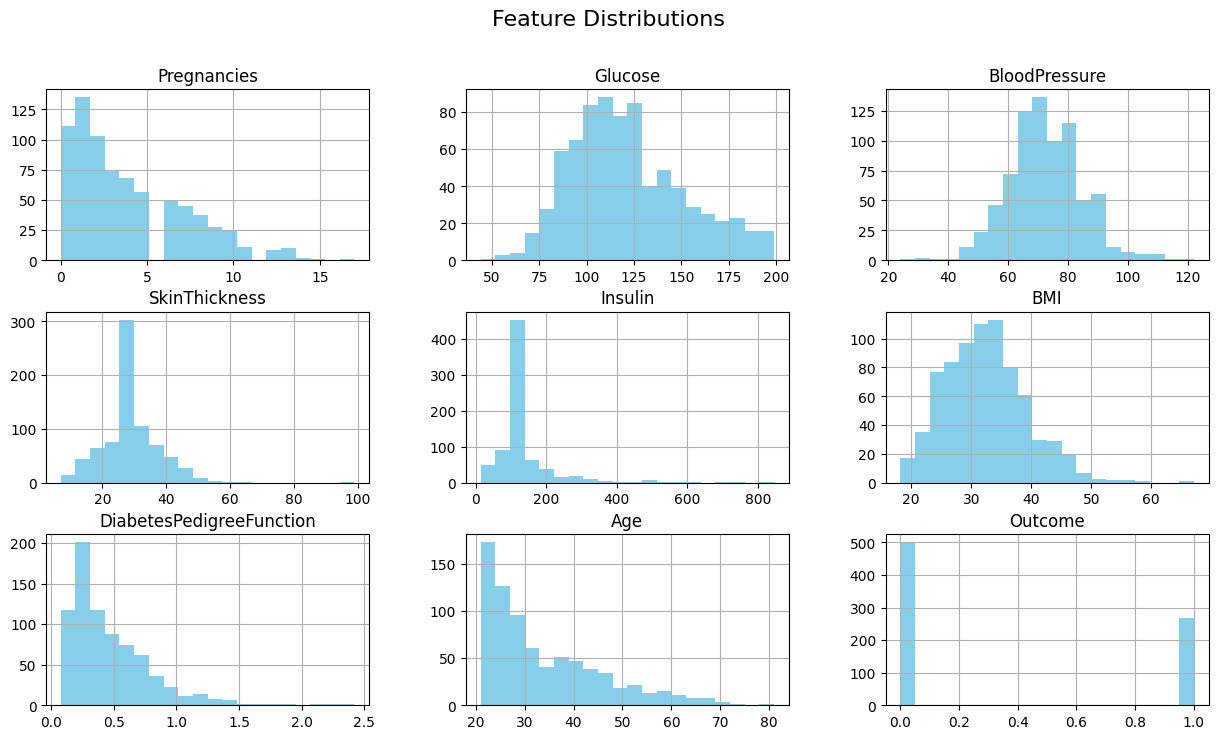

In [11]:
# Histograms of features
df.hist(bins=20, figsize=(15,8), color="skyblue")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [12]:
bp_outliers = df[df['BloodPressure'] < 40]
print("Number of records with BloodPressure < 40:", len(bp_outliers))

# Display them
print(bp_outliers)

Number of records with BloodPressure < 40: 4
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
18             1    103.0           30.0           38.0     83.0  43.3   
125            1     88.0           30.0           42.0     99.0  55.0   
597            1     89.0           24.0           19.0     25.0  27.8   
599            1    109.0           38.0           18.0    120.0  23.1   

     DiabetesPedigreeFunction  Age  Outcome  
18                      0.183   33        0  
125                     0.496   26        1  
597                     0.559   21        0  
599                     0.407   26        0  


In [13]:
df['BloodPressure'] = df['BloodPressure'].apply(lambda x: 40 if x < 40 else x)


In [14]:
insulin_outliers = df[df['Insulin'] >500]
print("Number of records with insulin > 500:", len(insulin_outliers))

# Display them
print(insulin_outliers)

Number of records with insulin > 500: 9
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
8              2    197.0           70.0           45.0    543.0  30.5   
13             1    189.0           60.0           23.0    846.0  30.1   
228            4    197.0           70.0           39.0    744.0  36.7   
247            0    165.0           90.0           33.0    680.0  52.3   
286            5    155.0           84.0           44.0    545.0  38.7   
409            1    172.0           68.0           49.0    579.0  42.4   
584            8    124.0           76.0           24.0    600.0  28.7   
655            2    155.0           52.0           27.0    540.0  38.7   
753            0    181.0           88.0           44.0    510.0  43.3   

     DiabetesPedigreeFunction  Age  Outcome  
8                       0.158   53        1  
13                      0.398   59        1  
228                     2.329   31        0  
247                     0.427   23 

In [15]:
# Cap extreme insulin values at 300 (upper realistic bound)
df['Insulin'] = df['Insulin'].apply(lambda x: 300 if x > 300 else x)


In [16]:
skin_thickness_outliers = df[df['SkinThickness'] > 60]
print("Number of records with SkinThickness > 60:", len(skin_thickness_outliers))

# Display them
print(skin_thickness_outliers)

Number of records with SkinThickness > 60: 2
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
445            0    180.0           78.0           63.0     14.0  59.4   
579            2    197.0           70.0           99.0    125.0  34.7   

     DiabetesPedigreeFunction  Age  Outcome  
445                     2.420   25        1  
579                     0.575   62        1  


In [17]:
# Capping SkinThickness values outside [10, 60]
# Define lower and upper bounds
lower_cap = 10
upper_cap = 60

df['SkinThickness'] = np.where(df['SkinThickness'] < lower_cap, lower_cap, df['SkinThickness'])
df['SkinThickness'] = np.where(df['SkinThickness'] > upper_cap, upper_cap, df['SkinThickness'])

# Check if capping worked
print("Min:", df['SkinThickness'].min())
print("Max:", df['SkinThickness'].max())


Min: 10.0
Max: 60.0


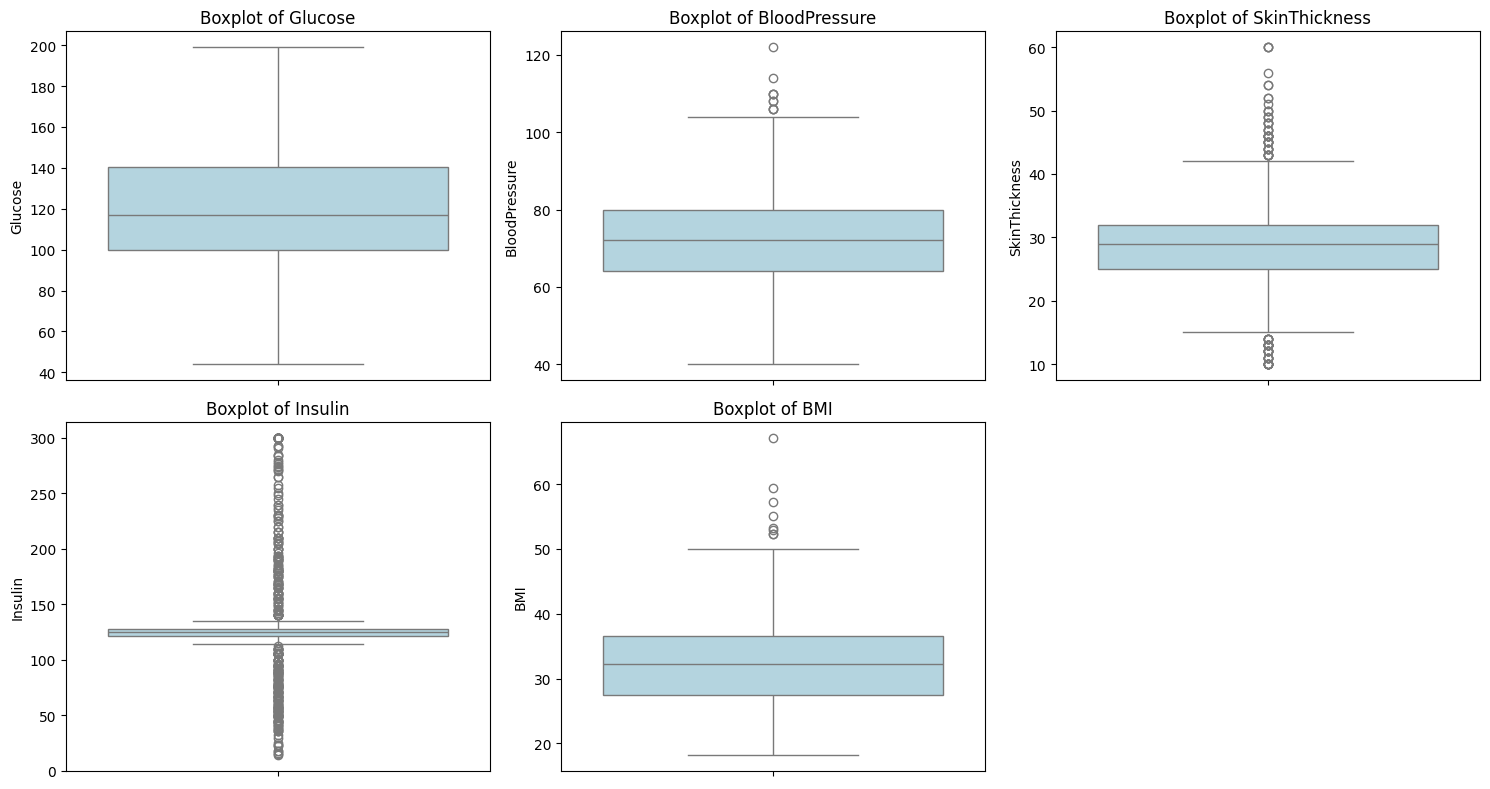

In [18]:
# Boxplots for outlier detection
plt.figure(figsize=(15,8))
for i, col in enumerate(["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color="lightblue")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

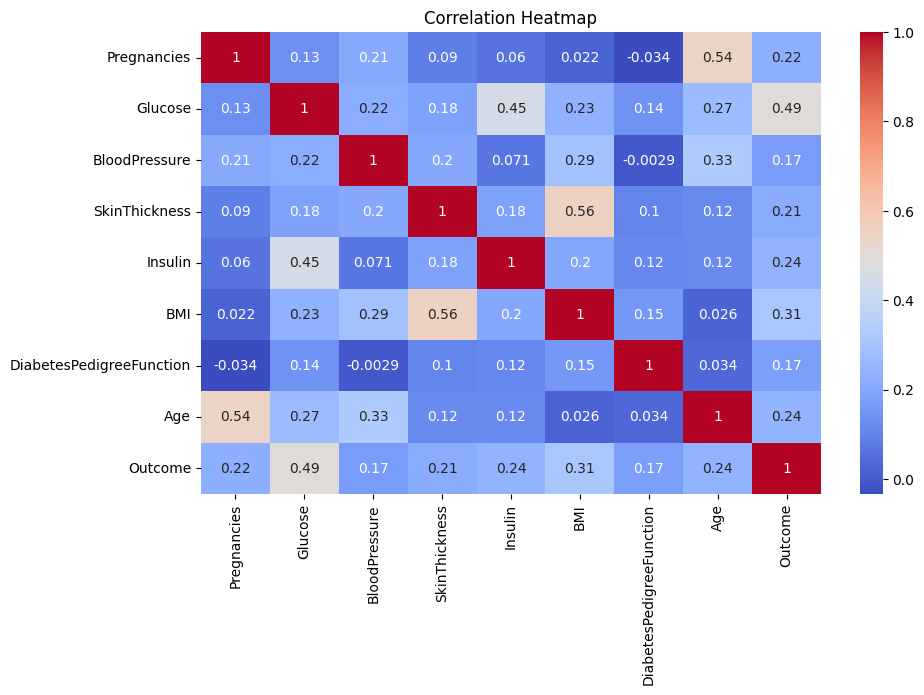

In [19]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [20]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Checking the distribution of Outcome Variable
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [23]:
X_train.shape

(614, 8)

In [24]:
# # Apply SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [25]:
X_train.shape

(800, 8)

In [26]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
models = {
"Logistic Regression": LogisticRegression(max_iter=500),
"Decision Tree": DecisionTreeClassifier(random_state=42),
"Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
"XGBoost": XGBClassifier( eval_metric='logloss', random_state=42),
"CatBoost": CatBoostClassifier(verbose=0, random_state=42),
"KNN": KNeighborsClassifier(n_neighbors=9)
}


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.73      0.77       100
           1       0.58      0.69      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



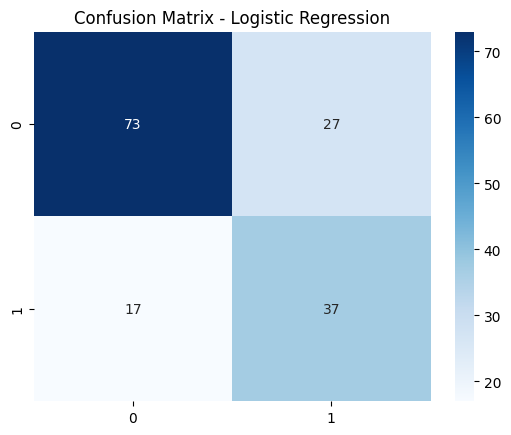


Model: Decision Tree
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       100
           1       0.61      0.61      0.61        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



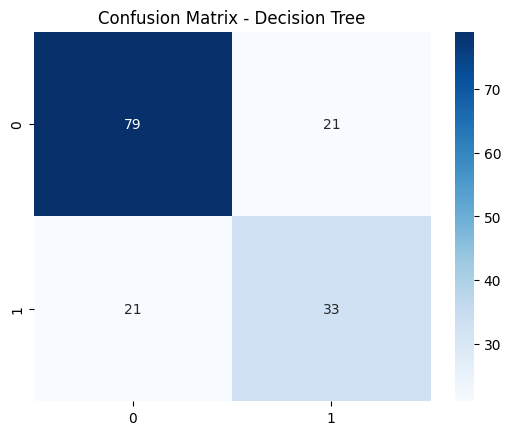


Model: Random Forest
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



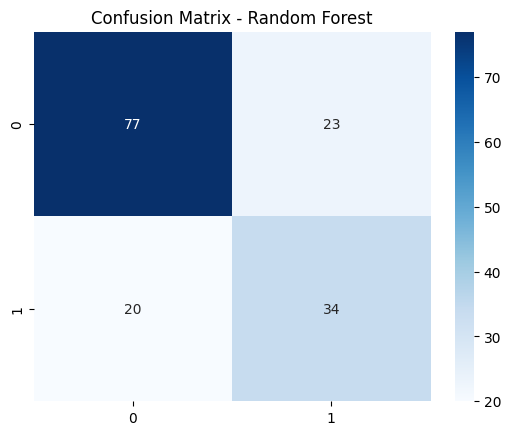


Model: XGBoost
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       100
           1       0.61      0.63      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



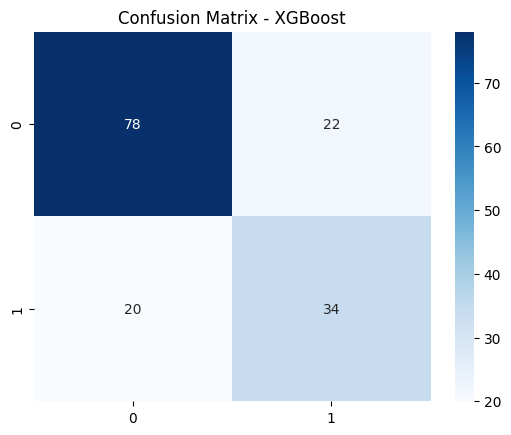


Model: CatBoost
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



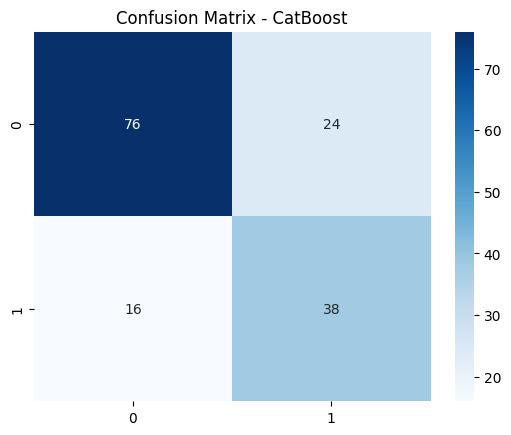


Model: KNN
              precision    recall  f1-score   support

           0       0.82      0.66      0.73       100
           1       0.54      0.74      0.62        54

    accuracy                           0.69       154
   macro avg       0.68      0.70      0.68       154
weighted avg       0.73      0.69      0.70       154



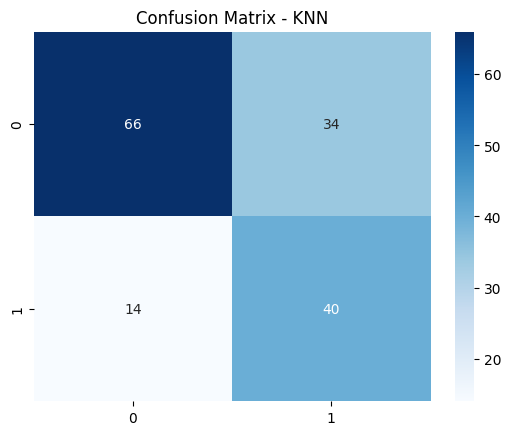

In [28]:
results = []


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec =precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    results.append([name, acc, prec, rec, f1, auc])
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues') 
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

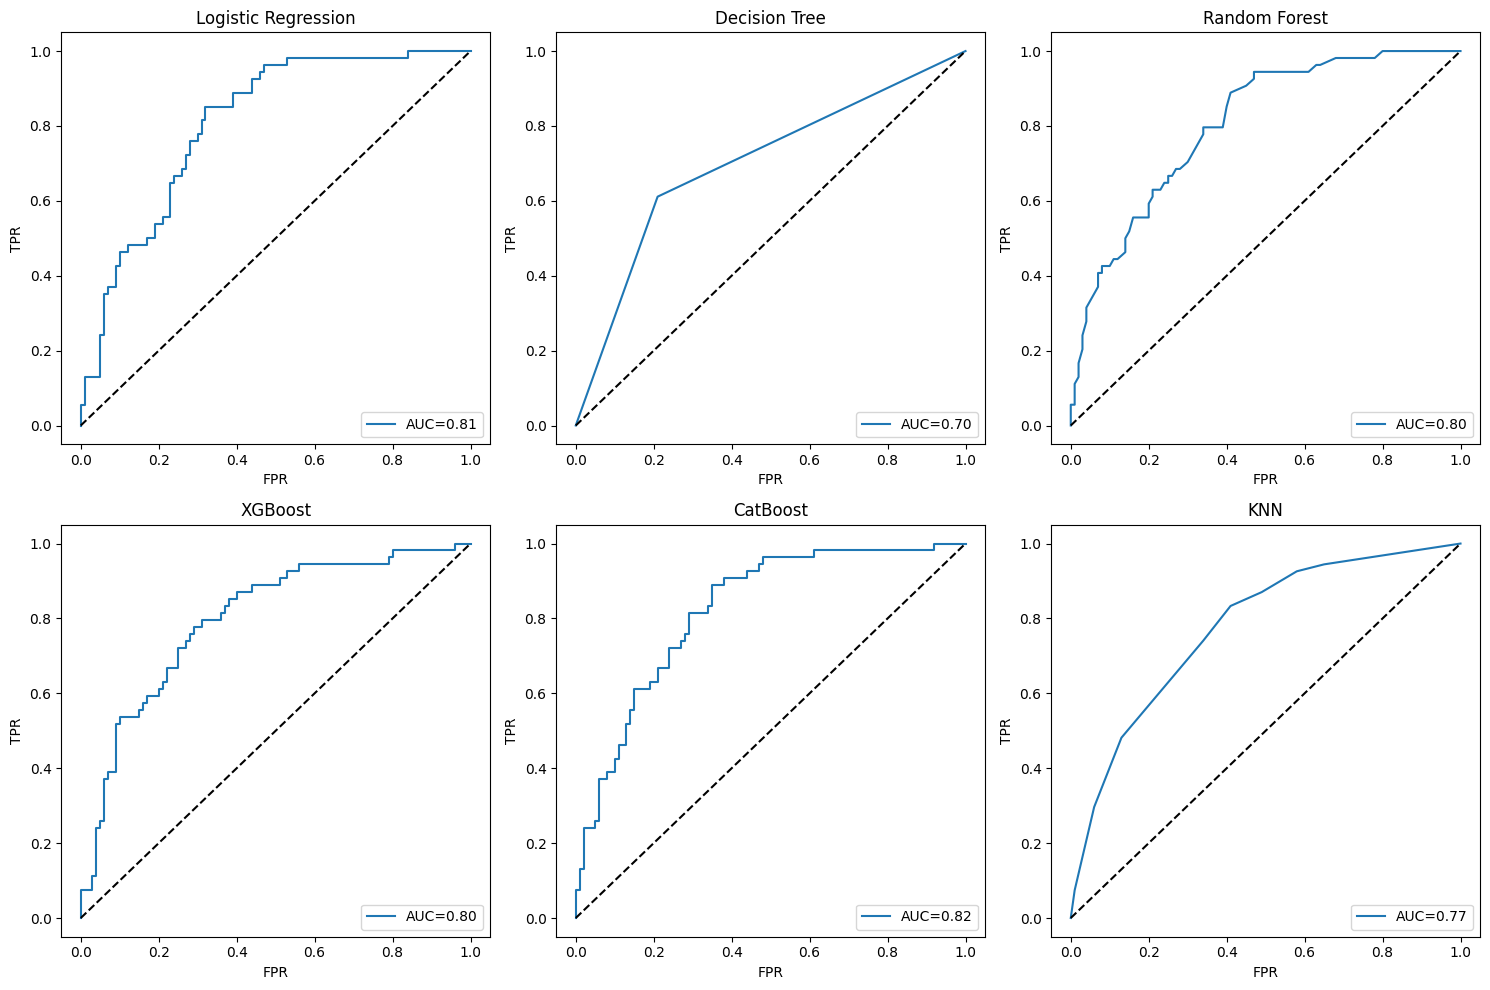

In [29]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(15, 10))

for i, (name, model) in enumerate(models.items(), 1):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    # create subplot (2 rows, 3 columns if 6 models)
    plt.subplot(2, 3, i)
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    plt.plot([0,1],[0,1],'k--')
    plt.title(name)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


In [30]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])
print("\nModel Comparison:\n")
print(results_df.sort_values(by="F1 Score", ascending=False))


Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
4             CatBoost  0.740260   0.612903  0.703704  0.655172  0.821852
0  Logistic Regression  0.714286   0.578125  0.685185  0.627119  0.807593
5                  KNN  0.688312   0.540541  0.740741  0.625000  0.775000
3              XGBoost  0.727273   0.607143  0.629630  0.618182  0.798519
2        Random Forest  0.720779   0.596491  0.629630  0.612613  0.803704
1        Decision Tree  0.727273   0.611111  0.611111  0.611111  0.700556


In [31]:
rf_params = {
'n_estimators': [100, 200, 300],
'max_depth': [None, 5, 10, 20],
'min_samples_split': [2, 5, 10],
'min_samples_leaf': [1, 2, 4]
}
rf_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, n_iter=10, scoring='f1', random_state=42, n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

In [32]:
xgb_params = {
'n_estimators': [100, 200, 300],
'max_depth': [3, 5, 7],
'learning_rate': [0.01, 0.05, 0.1],
'subsample': [0.8, 1.0],
'colsample_bytree': [0.8, 1.0]
}
xgb_grid = RandomizedSearchCV(XGBClassifier(eval_metric='logloss', random_state=42), xgb_params, cv=5, n_iter=10, scoring='f1', random_state=42, n_jobs=-1)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_

In [33]:
# Evaluate tuned models
rf_pred = rf_best.predict(X_test)
xgb_pred = xgb_best.predict(X_test)


rf_scores = [accuracy_score(y_test, rf_pred), precision_score(y_test, rf_pred), recall_score(y_test, rf_pred), f1_score(y_test, rf_pred), roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1])]
xgb_scores = [accuracy_score(y_test, xgb_pred), precision_score(y_test, xgb_pred), recall_score(y_test, xgb_pred), f1_score(y_test, xgb_pred), roc_auc_score(y_test, xgb_best.predict_proba(X_test)[:,1])]

In [34]:
cat_params = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'iterations': [300, 600, 900, 1200],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

cat_grid = RandomizedSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    param_distributions=cat_params,
    cv=5,
    n_iter=15,
    scoring='f1',
    n_jobs=-1
)

cat_grid.fit(X_train, y_train)

cat_best = cat_grid.best_estimator_
cat_pred = cat_best.predict(X_test)

cat_scores = [
    accuracy_score(y_test, cat_pred),
    precision_score(y_test, cat_pred),
    recall_score(y_test, cat_pred),
    f1_score(y_test, cat_pred),
    roc_auc_score(y_test, cat_best.predict_proba(X_test)[:,1])
]


In [35]:
tuned_results = pd.DataFrame([
    ["Tuned Random Forest", rf_scores[0], rf_scores[1], rf_scores[2], rf_scores[3], rf_scores[4]],
    ["Tuned XGBoost",      xgb_scores[0], xgb_scores[1], xgb_scores[2], xgb_scores[3], xgb_scores[4]],
    ["Tuned CatBoost",     cat_scores[0], cat_scores[1], cat_scores[2], cat_scores[3], cat_scores[4]]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])
print(tuned_results.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Tuned Random Forest  0.746753   0.627119  0.685185  0.654867  0.818148
1        Tuned XGBoost  0.733766   0.603175  0.703704  0.649573  0.830556
2       Tuned CatBoost  0.720779   0.600000  0.611111  0.605505  0.794630


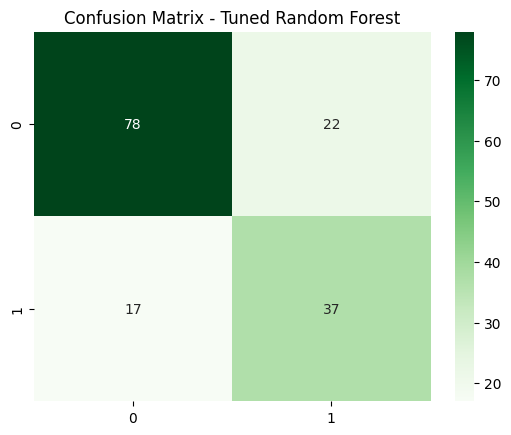

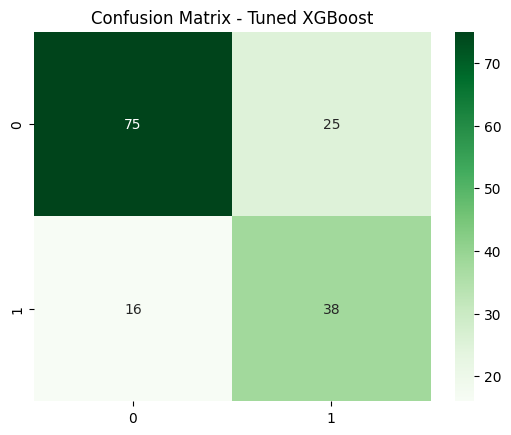

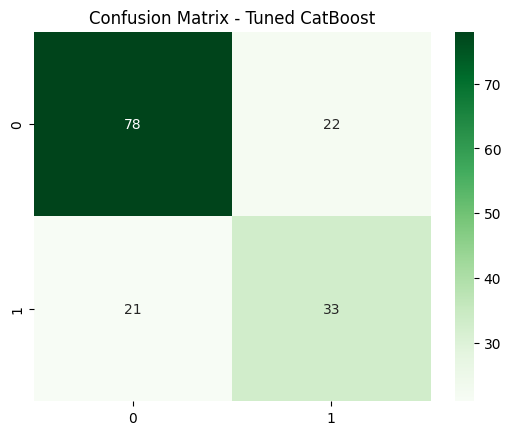

In [36]:
# Confusion Matrices for tuned models
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()


sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

sns.heatmap(confusion_matrix(y_test, cat_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Tuned CatBoost")
plt.show()

In [37]:
cat_boost=CatBoostClassifier(verbose=0, random_state=42)
cat_boost.fit(X_train,y_train)

In [38]:
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    )),
    
    ('xgb', XGBClassifier(
        eval_metric='logloss',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )),
    
    ('cat', CatBoostClassifier(
        iterations=600,
        depth=6,
        learning_rate=0.05,
        verbose=0,
        random_state=42
    ))
]

# META MODEL (Logistic Regression)
meta_model = LogisticRegression(max_iter=500)

# STACKING CLASSIFIER
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method='predict_proba',
    passthrough=False,
    cv=5,
    n_jobs=-1
)


# FIT STACKING MODEL
stack_model.fit(X_train, y_train)

# PREDICTION
stack_pred = stack_model.predict(X_test)
stack_prob = stack_model.predict_proba(X_test)[:,1]


stack_acc = accuracy_score(y_test, stack_pred)
stack_prec = precision_score(y_test, stack_pred)
stack_rec = recall_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)
stack_auc = roc_auc_score(y_test, stack_prob)

print("STACKING MODEL PERFORMANCE:")
print("Accuracy :", stack_acc)
print("Precision:", stack_prec)
print("Recall   :", stack_rec)
print("F1 Score :", stack_f1)
print("ROC-AUC  :", stack_auc)

STACKING MODEL PERFORMANCE:
Accuracy : 0.7662337662337663
Precision: 0.6607142857142857
Recall   : 0.6851851851851852
F1 Score : 0.6727272727272727
ROC-AUC  : 0.8275925925925925


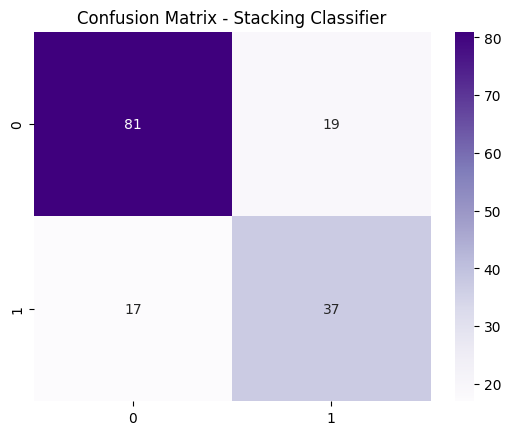

In [39]:
# Confusion Matrix for Stacking
sns.heatmap(confusion_matrix(y_test, stack_pred), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Stacking Classifier")
plt.show()

In [40]:
stack_row = pd.DataFrame([
    ["Stacking Classifier", stack_acc, stack_prec, stack_rec, stack_f1, stack_auc]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

final_results = pd.concat([results_df, tuned_results, stack_row], ignore_index=True)
print(final_results.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
9  Stacking Classifier  0.766234   0.660714  0.685185  0.672727  0.827593
4             CatBoost  0.740260   0.612903  0.703704  0.655172  0.821852
6  Tuned Random Forest  0.746753   0.627119  0.685185  0.654867  0.818148
7        Tuned XGBoost  0.733766   0.603175  0.703704  0.649573  0.830556
0  Logistic Regression  0.714286   0.578125  0.685185  0.627119  0.807593
5                  KNN  0.688312   0.540541  0.740741  0.625000  0.775000
3              XGBoost  0.727273   0.607143  0.629630  0.618182  0.798519
2        Random Forest  0.720779   0.596491  0.629630  0.612613  0.803704
1        Decision Tree  0.727273   0.611111  0.611111  0.611111  0.700556
8       Tuned CatBoost  0.720779   0.600000  0.611111  0.605505  0.794630


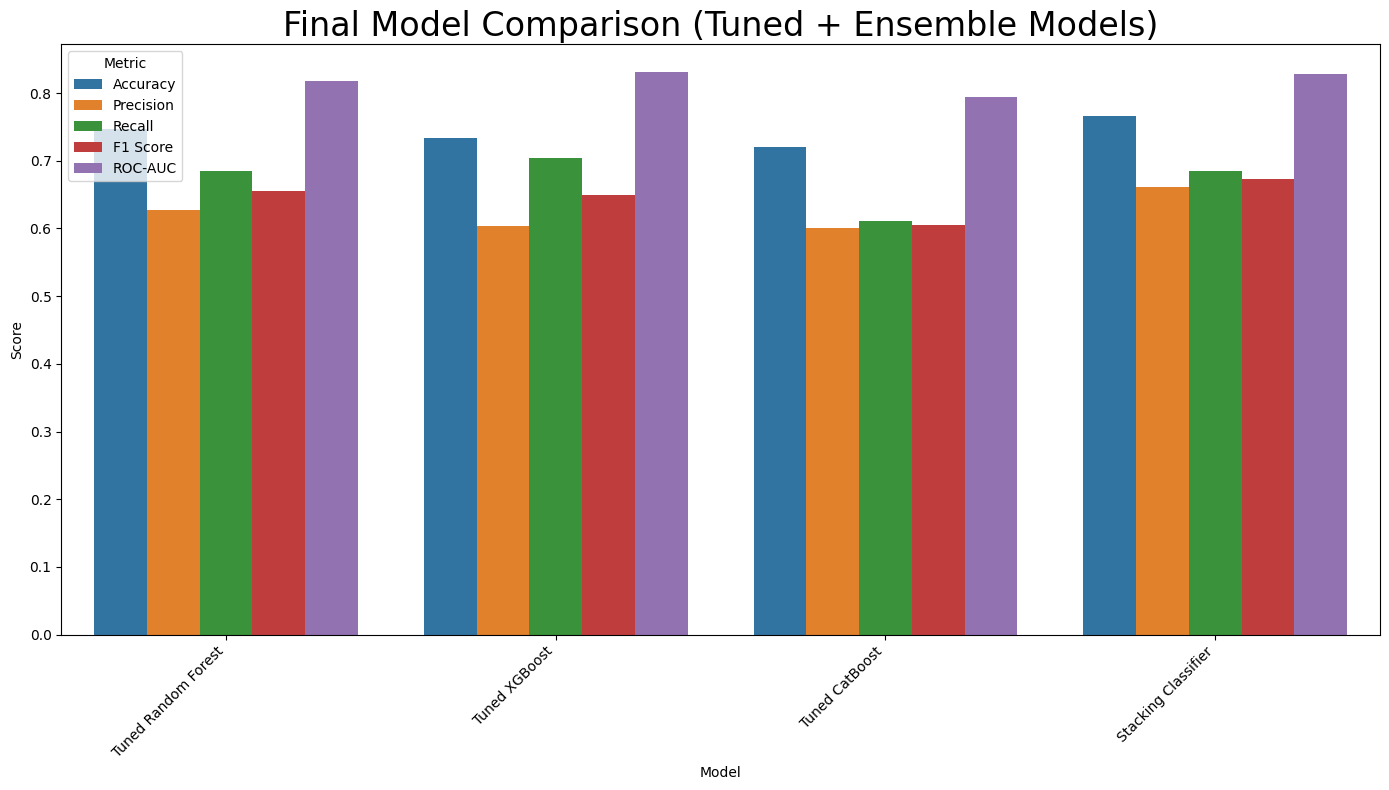

In [41]:
# Metrics list
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

# Create DataFrame for BEST models only
best_models_df = pd.DataFrame([
    ["Tuned Random Forest", *rf_scores],
    ["Tuned XGBoost", *xgb_scores],
    ["Tuned CatBoost", *cat_scores],
    ["Stacking Classifier", stack_acc, stack_prec, stack_rec, stack_f1, stack_auc]
], columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

# Melt for visualization
best_models_melted = best_models_df.melt(
    id_vars=["Model"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 8))
sns.barplot(data=best_models_melted, x="Model", y="Score", hue="Metric")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Final Model Comparison (Tuned + Ensemble Models)", fontsize=24)
plt.tight_layout()
plt.show()


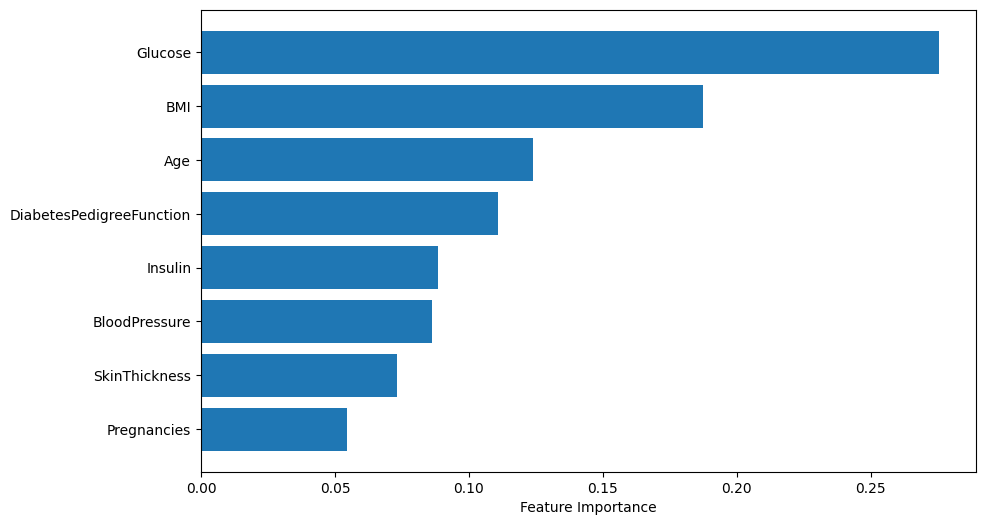

In [42]:
importances = rf_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(np.array(X.columns)[indices], importances[indices])
plt.xlabel("Feature Importance")
plt.show()

In [43]:
import os
from pathlib import Path
import joblib

# Change working directory to project root
os.chdir(r"c:\Users\hp\Desktop\GURPREET ML MODEL")

# Verify
print(os.getcwd())  

# Ensure saved_models folder exists
Path("saved_models").mkdir(exist_ok=True)

# Save scaler
joblib.dump(scaler, "saved_models/diabetes_scaler.joblib")

# Save model (if not done already)
joblib.dump(stack_model, "saved_models/diabetes_disease.joblib")

print("Model and scaler saved successfully!")


c:\Users\hp\Desktop\GURPREET ML MODEL
Model and scaler saved successfully!


In [44]:
input_data = np.array([0, 95, 60, 20, 90, 22.5, 0.25, 25]).reshape(1, -1)
input_data_scaled = scaler.transform(input_data)   # Use the same scaler used during training

prediction = stack_model.predict(input_data_scaled)
if prediction[0] == 0:
    print("The person is not diabetic")
else:
    print("The person is diabetic")

The person is not diabetic
